<a href="https://colab.research.google.com/github/tnencini3-cmyk/Es7/blob/main/07-integrazione.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Laboratorio di Introduzione alla Matematica Computazionale - Esercizi in Julia**

## **Esercitazione 7: Calcolo numerico di integrali**

Supponiamo di avere una funzione reale continua di variabile reale

$$f:[a,b]\longrightarrow\mathbb{R}.$$

Ci poniamo il problema di approssimare numericamente l'integrale

$$
\int_a^b f(x)dx.
$$

In questa esercitazione vedremo alcuni metodi classici concepiti per risolvere il problema. L'idea generale alla base di questi metodi consiste nel suddividere l'intervallo $[a,b]$ in tanti piccoli sottointervalli e, su ciascun sottointervallo, approssimare $f$ per mezzo di una funzione più semplice (per esempio lineare o polinomiale). Osserviamo che, per applicare questi metodi, non è necessario conoscere esplicitamente l'espressione della funzione $f$; è sufficiente saperla valutare in certi punti dell'intervallo $[a,b]$.  

---
# Setup iniziale
Carichiamo le librerie necessarie (in particolare `QuadGK`, che contiene funzionalità Julia per approssimare numericamente gli integrali).

In [2]:
import Pkg; Pkg.add( "QuadGK" )

using Plots
using QuadGK

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/.julia/environments/v1.11/Project.toml`
  [1fd47b50] + QuadGK v2.11.2
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


Nota: se le istruzioni precedenti danno errore, potrebbe essere necessario caricare la libreria con le istruzioni
```julia
import Pkg; Pkg.add( "QuadGK" )
```

---
# 1. Metodo dei trapezi


Suddividiamo l'intervallo $[a,b]$ in $N$ sottointervalli $[t_i,t_{i+1}]$, ciascuno di ampiezza $h=\frac{b-a}{N}$. Avremo quindi

$$
t_i=a + i\,h,\qquad i=0,\ldots , N.
$$

In ciascun sottointervallo l'integrale viene approssimato come l'area del trapezio di altezza $h$ le cui basi sono il segmento di estremi $(t_i,0)$, $(t_i,f(t_i))$ e il segmento di estremi $(t_{i+1},0)$, $(t_{i+1},f(t_{i+1}))$. Le aree dei trapezi così determinati vengono sommate per approssimare l'integrale cercato. La formula che ne deriva è

$$
\int_a^b f(x)dx\approx h\left(\frac{f(a)+f(b)}{2}+
\sum_{j=1}^{N-1}f(a+jh)\right).
$$  

Un esempio con $f(x)=0.5\,x^2$, $a=1$, $b=4$ e $N=3$  è illustrato nella figura qui sotto.

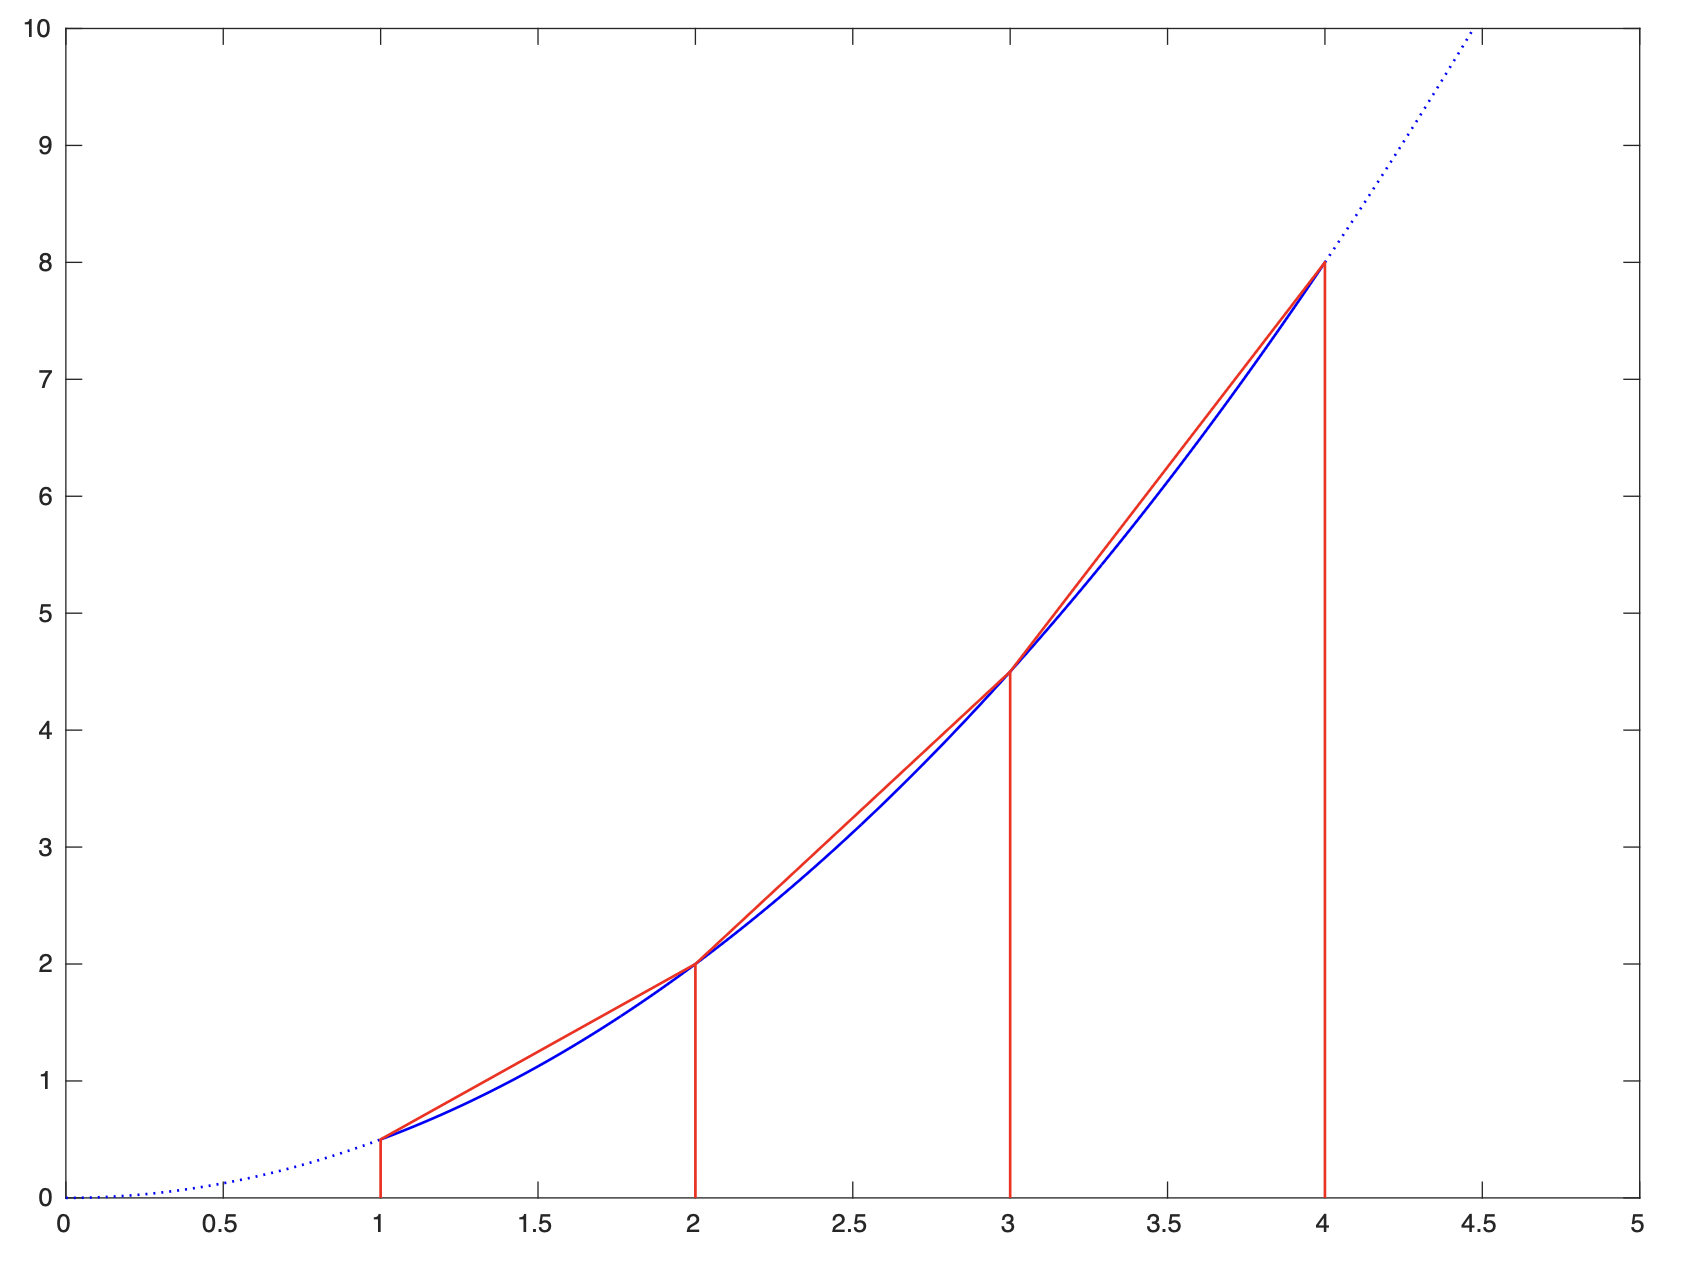


**Esercizio 1**. Scrivere una function `trapezi(f,a,b,N)` che prenda in ingresso

* una funzione `f`,
* gli estremi di integrazione `a` e `b`,
* il numero `N` di sottointervalli da usare,

e restituisca l'approssimazione `S` dell'integrale di `f` tra `a` e `b` ottenuta con il metodo dei trapezi.

In [24]:
function trapezi(f,a,b,N)
  h = (b - a)/N
  somma = sum([f(a + i*h) for i in 1:N-1], init=0) #Risultato della sommatoria, init = 0 serve a forzare Julia a restituire 0 nel momento in cui N = 1
  S = h*((f(a)+f(b))/2+somma)
  return S
end

trapezi (generic function with 1 method)

Verificate la correttezza dell'implementazione su un integrale noto, per esempio

$$
\int_0^1 e^xdx,
$$

che vale $e-1$. Sullo stesso esempio potete controllare che, come è ragionevole aspettarsi, l'accuratezza dell'approssimazione ottenuta migliora al crescere di $N$.

In [27]:
f(t) = exp(t)
a = 0
b = 1
N = 10
valore = trapezi(f, a, b, N)
errore = (exp(1)  - 1) - valore
errore_percentuale = abs(errore / (exp(1) - 1)) * 100
println("Approsimazione dell'integrale con N = $N: $valore, con errore di: $errore e errore percentuale di: $errore_percentuale%")
N = 100
valore = trapezi(f, a, b, N)
errore = (exp(1)  - 1) - valore
errore_percentuale = abs(errore / (exp(1) - 1)) * 100
println("Approsimazione dell'integrale con N = $N: $valore, con errore di: $errore e errore percentuale di: $errore_percentuale%" )
N = 1000
valore = trapezi(f, a, b, N)
errore = (exp(1)  - 1) - valore
errore_percentuale = abs(errore / (exp(1) - 1)) * 100
println("Approsimazione dell'integrale con N = $N: $valore, con errore di: $errore e errore percentuale di: $errore_percentuale%")
N = 10000
valore = trapezi(f, a, b, N)
errore = (exp(1)  - 1) - valore
errore_percentuale = abs(errore / (exp(1) - 1)) * 100
println("Approsimazione dell'integrale con N = $N: $valore, con errore di: $errore e errore percentuale di: $errore_percentuale%")

Approsimazione dell'integrale con N = 10: 1.7197134913893146, con errore di: -0.0014316629302695283 e errore percentuale di: 0.08331944775051502%
Approsimazione dell'integrale con N = 100: 1.7182961474504175, con errore di: -1.4318991372386236e-5 e errore percentuale di: 0.000833331944459164%
Approsimazione dell'integrale con N = 1000: 1.7182819716491962, con errore di: -1.43190151069561e-7 e errore percentuale di: 8.333333257558447e-6%
Approsimazione dell'integrale con N = 10000: 1.7182818298909472, con errore di: -1.4319021524045183e-9 e errore percentuale di: 8.333336992154821e-8%


**Esercizio 2**. Elaborando di più sul test appena fatto, si calcoli e rappresenti graficamente l'errore di approssimazione del metodo dei trapezi per $N$ crescente.  

Se la funzione da integrare è sufficientemente regolare, la teoria afferma che l'errore decresce proporzionalmente a $h^2$ (o, il che è equivalente, $1/N^2$). Verificate sperimentalmente questa proprietà. Starà a voi scegliere dei valori di $N$ opportuni.

(Suggerimento: potete rappresentare i valori di $N$ e gli errori in scala log-log, applicare un fit lineare e constatare che la pendenza della retta è vicina a $2$).

l'integrale approssimato vale: 1.7182819716491962
l'errore vale: 1.431901508475164e-7


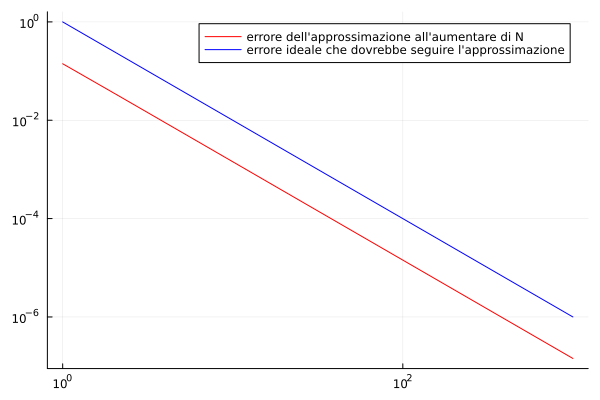

In [28]:
N = 1000
a = 0
b = 1
h = (b - a)/N
f(t) = exp(t)
S = trapezi(f,a,b,N)
I, _ = quadgk(f, a, b)
err = abs(S - I)
println("l'integrale approssimato vale: $S")
println("l'errore vale: $err")

#Questa parte era per visualizzare l'approssimazione come una curba spezzata sovrapposta alla cura originale.
#intervallo_x = a-0.5:0.01:b+0.5
#intervallo_y = f.(intervallo_x)
#intervallo_x_appr = a : h : b
#intervallo_y_appr = f.(intervallo_x_appr)
#plot(intervallo_x, intervallo_y, label="funzione", color=:red)
#plot!(intervallo_x_appr, intervallo_y_appr, label="funzione", color=:blue)

I, _ = quadgk(f, a, b) #ridondante ma per rendere il codice più pulito lo riscrivo
errori = [abs(trapezi(f, a, b, n) - I) for n in 1:N]
plot(1:1:N, errori, yaxis=:log10, xaxis=:log10, label="errore dell'approssimazione all'aumentare di N", color=:red)
err_x = 1:0.05:N
errf(t) = t^(-2)
err_y = errf.(err_x)
plot!(err_x, err_y, yaxis=:log10, xaxis=:log10, label="errore ideale che dovrebbe seguire l'approssimazione", color=:blue)

---
# 2. Metodo di Simpson


Come il metodo dei trapezi, anche il metodo di Simpson parte da una suddivisione di $[a,b]$ in sottointervalli. In questo caso, però, la funzione da integrare è approssimata localmente da un polinomio quadratico, anzichè da una funzione lineare. La formula di approssimazione associata al cosiddetto *metodo di Simpson composito* è:

$$
\int_a^b f(x)dx\approx\frac{h}{3}\left(f(a)+f(b)+2\sum_{j=1}^{N/2-1}f(a+2jh)+4\sum_{j=1}^{N/2}f(a+(2j-1)h)\right),
$$

dove si suppone che $N$ sia pari e, come al solito, si definisce $h=\frac{b-a}{N}$.

**Esercizio 3**. Come nell'Esercizio 1, scrivere una function `simpson(f,a,b,N)` che approssimi l'integrale di `f` tra `a` e `b` usando il metodo di Simpson con suddivisione in `N` intervalli, dove si assume che `N` sia pari.

In [42]:
function simpson(f,a,b,N)
  if N%2 != 0
    return "Inserire un N pari"
  end
  h = (b - a) / N
  first_sum = 2 * (sum([f(a + 2 * j * h) for j in 1:N/2-1], init = 0))
  second_sum = 4 * (sum([f(a + (2 * j - 1) * h) for j in 1:N/2], init = 0))
  S = (h / 3) * (f(a) + f(b) + first_sum + second_sum)
end

simpson (generic function with 1 method)


Si testi quindi la function `simpson`. Come nell'Esercizio 2, si stimi sperimentalmente la convergenza dell'errore di approssimazione all'aumentare di `N`, cioè al diminuire di $h$. Che risultato trovate?

In [44]:
f(t) = exp(t)
a = 0
b = 1

#test per mostrare come con un numero dispari la funzione restituisa errore
N = 11
valore = simpson(f, a, b, N)
println("$valore (N = $N)")

N = 10
valore = simpson(f, a, b, N)
errore = (exp(1)  - 1) - valore
errore_percentuale = abs(errore / (exp(1) - 1)) * 100
println("Approsimazione dell'integrale con N = $N: $valore, con errore di: $errore e errore percentuale di: $errore_percentuale%")
N = 100
valore = simpson(f, a, b, N)
errore = (exp(1)  - 1) - valore
errore_percentuale = abs(errore / (exp(1) - 1)) * 100
println("Approsimazione dell'integrale con N = $N: $valore, con errore di: $errore e errore percentuale di: $errore_percentuale%" )
N = 1000
valore = simpson(f, a, b, N)
errore = (exp(1)  - 1) - valore
errore_percentuale = abs(errore / (exp(1) - 1)) * 100
println("Approsimazione dell'integrale con N = $N: $valore, con errore di: $errore e errore percentuale di: $errore_percentuale%")
N = 10000
valore = simpson(f, a, b, N)
errore = (exp(1)  - 1) - valore
errore_percentuale = abs(errore / (exp(1) - 1)) * 100
println("Approsimazione dell'integrale con N = $N: $valore, con errore di: $errore e errore percentuale di: $errore_percentuale%")
print("Si osservi come per stessi N il risultato ottenuto è molto più accurato rispetto all'apporossimazione per trapezi")

Inserire un N pari (N = 11)
Approsimazione dell'integrale con N = 10: 1.7182827819248236, con errore di: -9.53465778552598e-7 e errore percentuale di: 5.548948739146394e-5%
Approsimazione dell'integrale con N = 100: 1.7182818285545045, con errore di: -9.545941814792513e-11 e errore percentuale di: 5.555515781339149e-9%
Approsimazione dell'integrale con N = 1000: 1.7182818284590553, con errore di: -1.021405182655144e-14 e errore percentuale di: 5.944340245809036e-13%
Approsimazione dell'integrale con N = 10000: 1.7182818284590444, con errore di: 6.661338147750939e-16 e errore percentuale di: 3.8767436385711106e-14%
Si osservi come per stessi N il risultato ottenuto è molto più accurato rispetto all'apporossimazione per trapezi

---
# 3. Funzioni di quadratura in Julia


Il pacchetto `QuadGK' in Julia implementa funzioni di quadratura numerica per funzioni scalari di una variabile, con scelta automatica (adattiva) del passo di integrazione, usando le formule di quadratura di Gauss–Kronrod.

La funzione `quadgk` prende in input la funzione integranda `f`, gli estremi dell'intervallo di integrazione `a` e `b` e restituisce in output due valori, il primo e' l'approssimazione dell'intergale, il secondo e' l'errore stimato dell'approssimazione.

Ad esempio, per approssimare $\int_0^\pi \sin(x)e^{-x} dx$, eseguiamo i comandi

```julia
# Definiamo la funzione integranda
g(x) = sin(x) * exp(-x)

# Calcoliamo l'integrale da 0 a π
risultato, errore = quadgk(g, 0, pi)

println("Risultato: ", risultato)
println("Accuratezza: ", errore)



**Esercizio 4**. Consideriamo la curva parametrica nel piano di equazioni
\begin{eqnarray*}
&& x(t)=\int_0^t \cos(u^2)du,\\
&& y(t)=\int_0^t\sin(u^2)du.
\end{eqnarray*}
Si disegni il grafico della curva $(x(t),y(t))$, con $t\in [-4\pi,4\pi]$, calcolando gli integrali con la funzione `quadgk`.

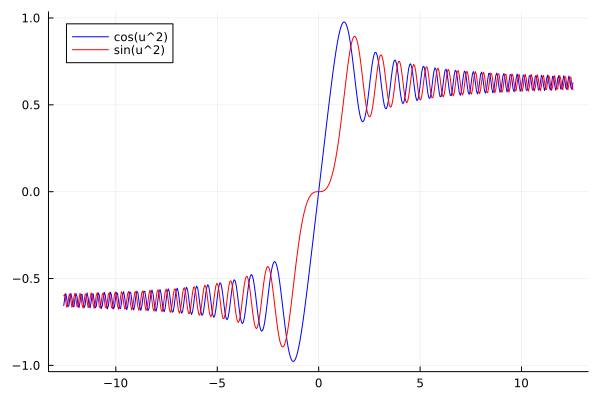

print device already activated


In [58]:
func_x(u) = cos(u^2)
func_y(u) = sin(u^2)

t = -4pi:0.05:4pi

x_risultato = [quadgk(func_x, 0, i)[1] for i in t]
y_risultato = [quadgk(func_y, 0, j)[1] for j in t]

plot(t, x_risultato, label="cos(u^2)", color=:blue)
plot!(t, y_risultato, label="sin(u^2)", color=:red)